In [63]:
%matplotlib inline
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
import langchain_google_genai
from pydantic import BaseModel,Field
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import Markdown,display
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor #RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler,OrdinalEncoder,StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [64]:
#We import the API key from our environment and configure llm 
api_key=os.environ.get("GOOGLE_API_KEY")
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash",temperature=0.5)

In [70]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "data_season.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "imtkaggleteam/agriculture-dataset-karnataka",
  file_path,
)
df.head()

,Year,Location,Area,Rainfall,Temperature,Soil type,Irrigation,yeilds,Humidity,Crops,price,Season
0,2004,Mangalore,1279,2903.1,27.0,Alluvial,Drip,2570.0,57.0,Coconut,200000,Kharif
1,2004,Mangalore,13283,2903.1,27.0,Alluvial,Drip,27170.0,57.5,Coconut,4847,Kharif
2,2004,Mangalore,52119,2903.1,27.0,Alluvial,Drip,114744.0,57.0,Coconut,51239,Kharif
3,2004,Mangalore,725,2996.6,27.0,Alluvial,Drip,1402.0,55.0,Coconut,216396,Kharif
4,2004,Mangalore,12885,2996.6,27.0,Alluvial,Drip,23456.0,56.0,Coconut,2644,Kharif


## Looking for null values ​​and outliers

In [4]:
#We analyze the dataset to see null values
print(df.isnull().sum())
print("")

Year            0
Location        0
Area            0
Rainfall        0
Temperature     0
Soil type      58
Irrigation      0
yeilds          0
Humidity        0
Crops           0
price           0
Season          0
dtype: int64



In [5]:
#We eliminate null values
df.dropna(inplace=True)
print(df.isnull().sum())

Year           0
Location       0
Area           0
Rainfall       0
Temperature    0
Soil type      0
Irrigation     0
yeilds         0
Humidity       0
Crops          0
price          0
Season         0
dtype: int64


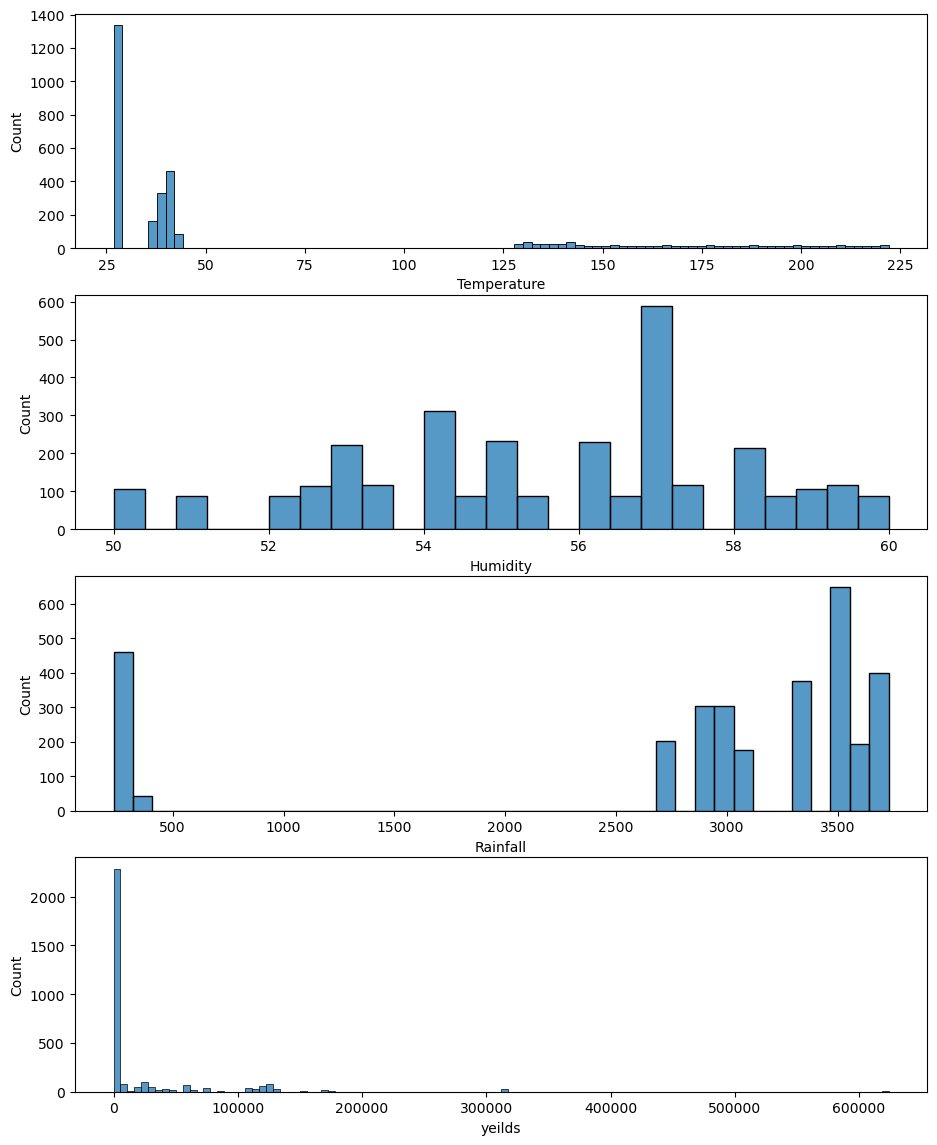

In [6]:
#Analyzing quantitative data to identify outliers
fig,ax=plt.subplots(nrows=4,ncols=1,figsize=(11,14))
ax1=ax[0]
ax2=ax[1]
ax3=ax[2]
ax4=ax[3]

sns.histplot(data=df,x="Temperature",ax=ax1)
sns.histplot(data=df,x="Humidity",ax=ax2)
sns.histplot(data=df,x="Rainfall",ax=ax3)
sns.histplot(data=df,x="yeilds",ax=ax4);

In [7]:
#Cleaning the dataset of outliers
cond1=df["yeilds"]<210000
df = df.loc[cond1]
cond2=df["Temperature"]<45
df=df.loc[cond2]

In [8]:
#We analyze the dataset to see basic information such as null data, mean, number of data points, etc.
print(df.describe())
print("")
print(df.info())

              Year          Area     Rainfall  Temperature         yeilds  \
count  2346.000000   2346.000000  2346.000000  2346.000000    2346.000000   
mean   2009.650043   9352.983802  2798.775831    32.566368   17686.136134   
std       5.153329  15137.038106  1172.508718     6.419755   37340.912132   
min    2004.000000      1.000000   233.000000    26.800000       2.000000   
25%    2004.000000    158.000000  2903.100000    27.000000     393.000000   
50%    2009.000000   2188.000000  3296.000000    27.200000    2628.000000   
75%    2015.000000  10912.000000  3522.800000    39.000000    5373.000000   
max    2019.000000  52119.000000  3729.800000    43.000000  177939.000000   

          Humidity          price  
count  2346.000000    2346.000000  
mean     55.589855   86324.217818  
std       2.468854   94250.190231  
min      50.000000     637.000000  
25%      54.000000    2644.000000  
50%      56.000000   45186.000000  
75%      57.000000  203317.000000  
max      60.000000

## Exploratory data analysis

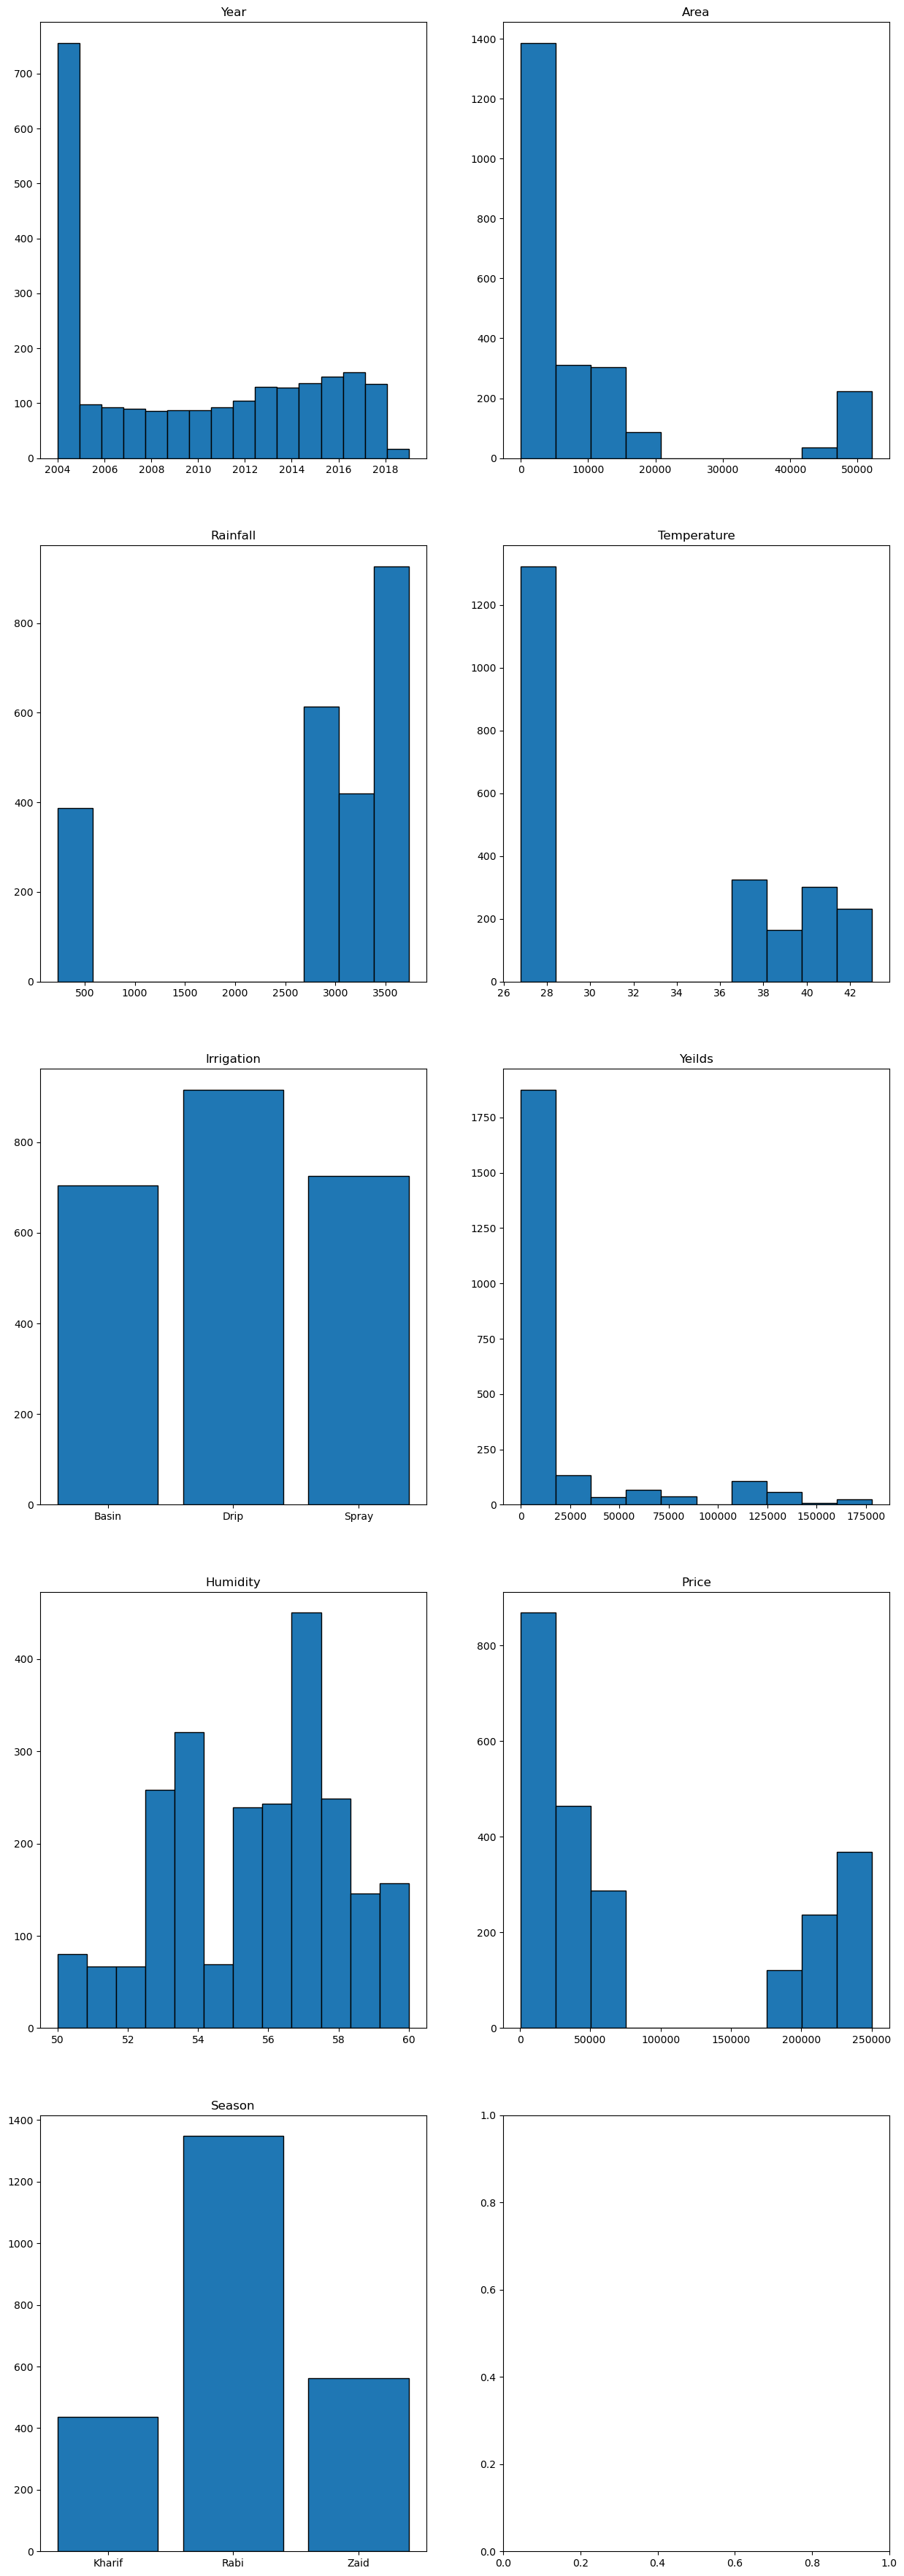

In [9]:
#Analyzing quantitative variables
fig,ax= plt.subplots(nrows=5,ncols=2,figsize=(15,45))
ax1=ax[0,0]
ax2=ax[0,1]
ax3=ax[1,0]
ax4=ax[1,1]
ax5=ax[2,0]
ax6=ax[2,1]
ax7=ax[3,0]
ax8=ax[3,1]
ax9=ax[4,0]

ax1.set_title("Year")
ax1.hist(df.Year,bins=16,edgecolor="Black")

ax2.set_title("Area")
ax2.hist(df["Area"],edgecolor="Black")

ax3.set_title("Rainfall")
ax3.hist(df["Rainfall"],edgecolor="Black")

ax4.set_title("Temperature")
ax4.hist(df["Temperature"],edgecolor="Black")

riego = df.Irrigation.value_counts().sort_index()
ax5.set_title("Irrigation")
ax5.bar(riego.index,riego.values,edgecolor="Black")

ax6.set_title("Yeilds")
ax6.hist(x=df["yeilds"],edgecolor="Black")

ax7.set_title("Humidity")
ax7.hist(df["Humidity"],bins=12,edgecolor="Black")

ax8.set_title("Price")
ax8.hist(df["price"],edgecolor="Black")

temporada=df["Season"].value_counts().sort_index()
ax9.set_title("Season")
ax9.bar(temporada.index,temporada.values,edgecolor="Black");

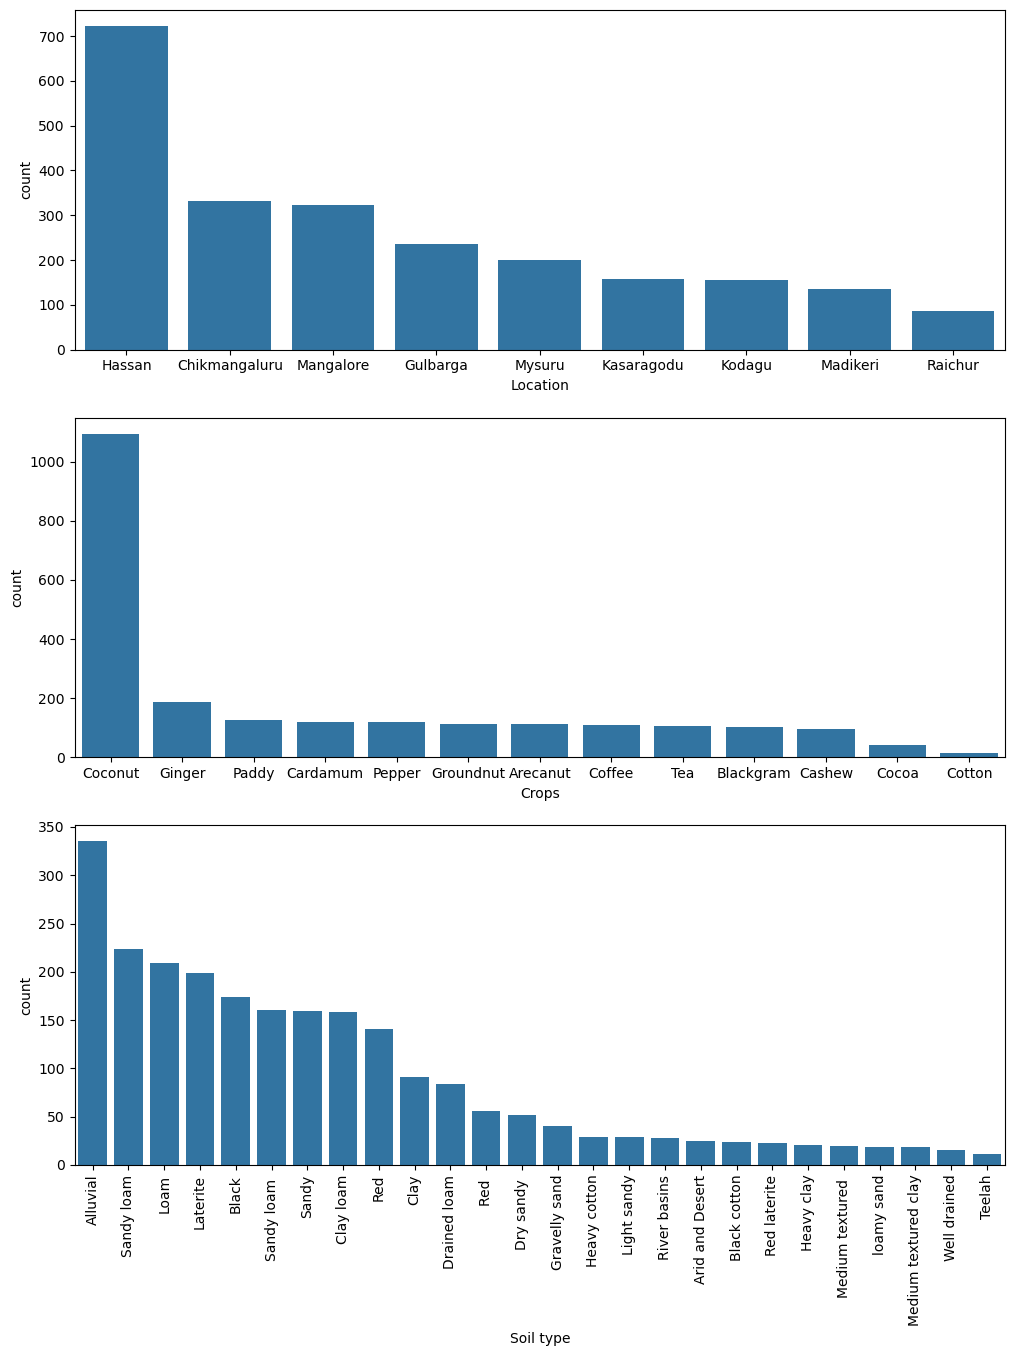

In [10]:
#Analizyng qualitatives variables
fig,ax=plt.subplots(nrows=3,ncols=1,figsize=(12,15))
ax1=ax[0]
ax2=ax[1]
ax3=ax[2]

localidad = df["Location"].value_counts().index
sns.countplot(data=df,x="Location",order=localidad,ax=ax1)
plt.xticks(rotation=90)
#plt.title("Localidad")
#plt.xlabel(None);

cultivos = df["Crops"].value_counts().index
sns.countplot(data=df,x="Crops",order=cultivos,ax=ax2)
#plt.title("Cultivos")
plt.xticks(rotation=90)
#plt.xlabel(None);

orden = df["Soil type"].value_counts().index
sns.countplot(data=df,x="Soil type",order=orden,ax=ax3)
plt.xticks(rotation=90);
#plt.title("Tipo de suelo")
#plt.xlabel(None);

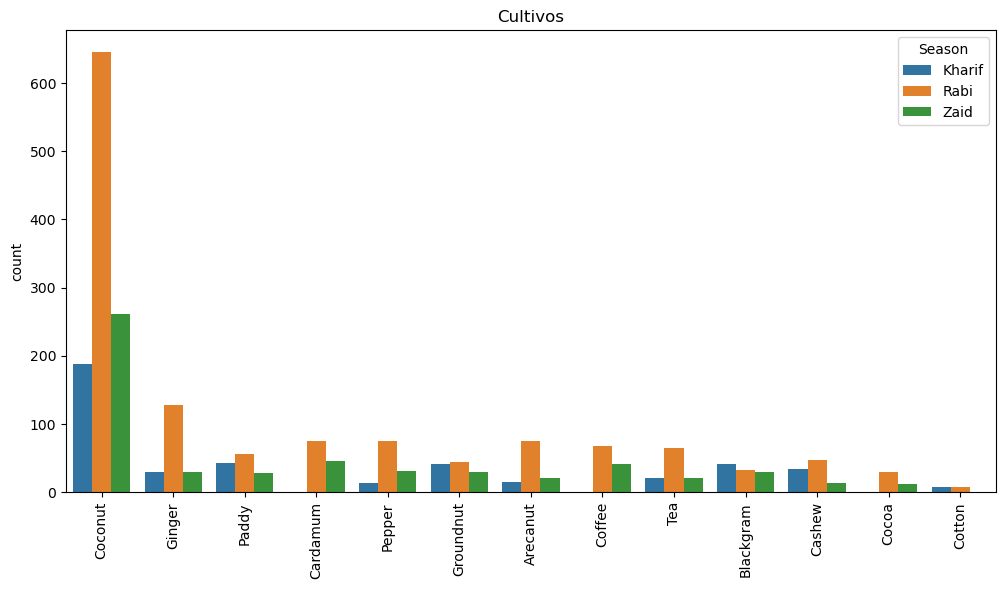

In [11]:
#Seasonal crops
cultivos = df["Crops"].value_counts().index
plt.figure(figsize=(12,6))
sns.countplot(data=df,x="Crops",order=cultivos,hue="Season")
plt.title("Cultivos")
plt.xticks(rotation=90)
plt.xlabel(None);

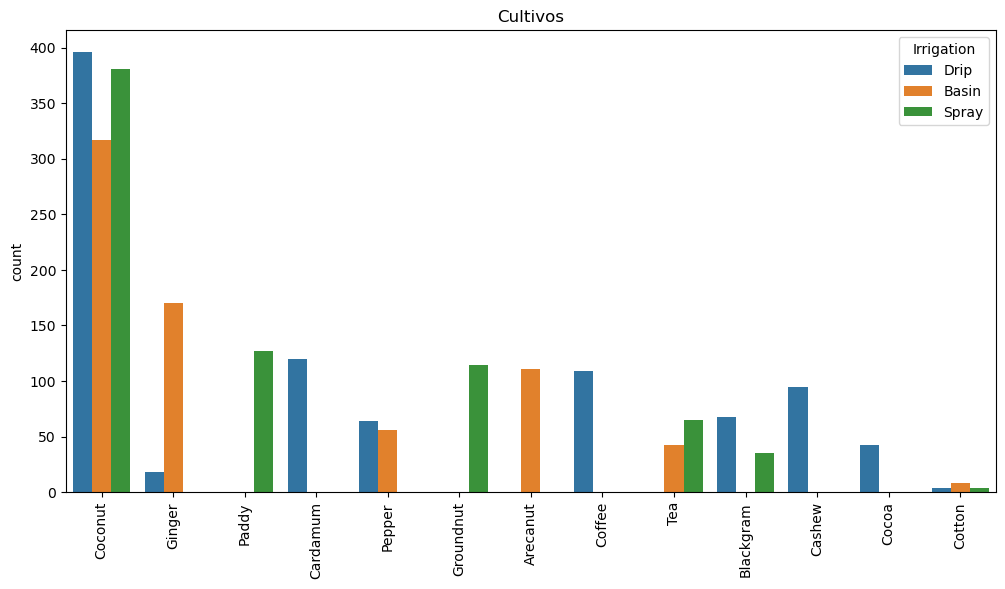

In [12]:
#Crops with different irrigation systems
cultivos = df["Crops"].value_counts().index
plt.figure(figsize=(12,6))
sns.countplot(data=df,x="Crops",order=cultivos,hue="Irrigation")
plt.title("Cultivos")
plt.xticks(rotation=90)
plt.xlabel(None);

In [70]:
df_string = df.to_string()
plantilla = ChatPromptTemplate.from_messages([
    ("system","You are an expert data scientist who professionally analyzes datasets and provides concise, well-explained answers. You will be given a dataset and will report which variables are related to each other, as well as offer advice on which charts are best to use."),
    ("user","Analize the following dataset {dataset}")
])
chain = plantilla|llm
respuesta = chain.invoke({"dataset":df_string})
display(Markdown(respuesta.content))

The provided dataset contains information about agricultural production across different locations, years, and environmental conditions.

### Variables and their Types:

*   **Categorical Variables:**
    *   `Year`: (Discrete, treated as categorical for trend analysis)
    *   `Location`: (Nominal)
    *   `Soil type`: (Nominal)
    *   `Irrigation`: (Nominal)
    *   `Crops`: (Nominal)
    *   `Season`: (Nominal)
*   **Numerical Variables:**
    *   `Area`: (Continuous) - Likely total area cultivated.
    *   `Rainfall`: (Continuous) - Total rainfall.
    *   `Temperature`: (Continuous) - Average temperature.
    *   `Humidity`: (Continuous) - Average humidity.
    *   `yields`: (Continuous) - Total yield (assuming this is total production, not yield per unit area, given its correlation with `Area`).
    *   `price`: (Continuous) - Total revenue/price (assuming this is total revenue, not price per unit, given its wide range and correlation with `yields`).

### Related Variables and Key Relationships:

The primary goal of analyzing this dataset would likely be to understand factors influencing `yields` and `price`.

1.  **Crop Performance and Value:**
    *   **`Crops` vs. `yields` and `price`**: This is a fundamental relationship. Different crops naturally have varying yields and market prices.
    *   **`Area` vs. `yields` and `price`**: Expect a strong positive correlation, as larger cultivated areas typically result in higher total yields and revenues.

2.  **Environmental Factors Impacting Production:**
    *   **`Rainfall`, `Temperature`, `Humidity` vs. `yields` and `price`**: These climatic conditions are crucial for crop growth. We'd look for optimal ranges or thresholds that maximize yields and prices for different crops.
    *   **`Soil type` vs. `yields` and `price` (and `Crops`)**: Certain soil types are more suitable for specific crops, directly affecting their productivity and thus yields and prices.
    *   **`Irrigation` vs. `yields` and `price` (and `Crops`)**: The method of irrigation can significantly influence water availability and, consequently, crop yields.

3.  **Geographical and Seasonal Influences:**
    *   **`Location` vs. `yields`, `price`, `Crops`, and environmental factors**: Different geographical locations will have distinct climatic conditions, soil types, and market dynamics, influencing what crops are grown and how well they perform.
    *   **`Season` vs. `yields`, `price`, `Crops`, and environmental factors**: Agricultural seasons dictate planting and harvesting times, affecting crop choices, yields, and market prices. Environmental factors like rainfall and temperature also vary by season.

4.  **Time Trends:**
    *   **`Year` vs. `yields` and `price`**: Analyzing trends over the years can reveal growth, decline, or stability in agricultural output and revenue.

5.  **Interactions (Multivariate Relationships):**
    *   **`Crops` x `Soil type` x `yields` / `price`**: Understanding which crops thrive in which soil types and how that impacts their output.
    *   **`Crops` x `Rainfall` / `Temperature` / `Humidity` x `yields` / `price`**: Identifying the ideal environmental conditions for each specific crop.
    *   **`Location` x `Crops` x `yields` / `price`**: Pinpointing which crops are most productive/profitable in specific regions.
    *   **`Season` x `Crops` x `yields` / `price`**: Analyzing seasonal variations in crop performance.

### Recommended Charts for Visualization:

To effectively explore these relationships, the following charts are recommended:

1.  **Histograms / Density Plots:**
    *   **Purpose:** To visualize the distribution of numerical variables like `Area`, `Rainfall`, `Temperature`, `Humidity`, `yields`, and `price`.
    *   **Example:** Histogram of `yields` to see its overall distribution.

2.  **Bar Charts:**
    *   **Purpose:** To compare the mean (or sum) of a numerical variable across different categories.
    *   **Examples:**
        *   Mean `yields` by `Crops`.
        *   Mean `price` by `Location`.
        *   Average `Rainfall` by `Season`.
        *   Sum of `Area` allocated to each `Crops`.

3.  **Box Plots / Violin Plots:**
    *   **Purpose:** To show the distribution (median, quartiles, outliers) of a numerical variable for each category. Violin plots add density estimation.
    *   **Examples:**
        *   `yields` distribution by `Crops`.
        *   `Temperature` distribution by `Location`.
        *   `price` distribution by `Soil type`.

4.  **Scatter Plots:**
    *   **Purpose:** To visualize the relationship between two numerical variables.
    *   **Examples:**
        *   `Area` vs. `yields` (expect a strong positive linear relationship).
        *   `Rainfall` vs. `yields`.
        *   `Temperature` vs. `price`.
        *   Adding a third categorical variable as color/hue (e.g., `Rainfall` vs. `yields`, colored by `Crops`) can reveal crop-specific patterns.

5.  **Line Plots:**
    *   **Purpose:** To visualize trends over time for numerical variables.
    *   **Examples:**
        *   Average `yields` per `Year`.
        *   Average `price` per `Year`.
        *   Average `Temperature` per `Year`.

6.  **Stacked Bar Charts:**
    *   **Purpose:** To show the composition of a categorical variable within another categorical variable.
    *   **Examples:**
        *   Distribution of `Crops` within each `Season`.
        *   Distribution of `Soil type` within each `Location`.

7.  **Heatmaps:**
    *   **Purpose:** To visualize the relationship between two categorical variables and a numerical variable (often the average or sum).
    *   **Examples:**
        *   Average `yields` for each `Crop` in each `Location`.
        *   Average `price` for each `Crop` in each `Season`.

By employing these visualizations, you can gain a comprehensive understanding of the interdependencies within your agricultural dataset and derive actionable insights.

## 2. Bar Charts

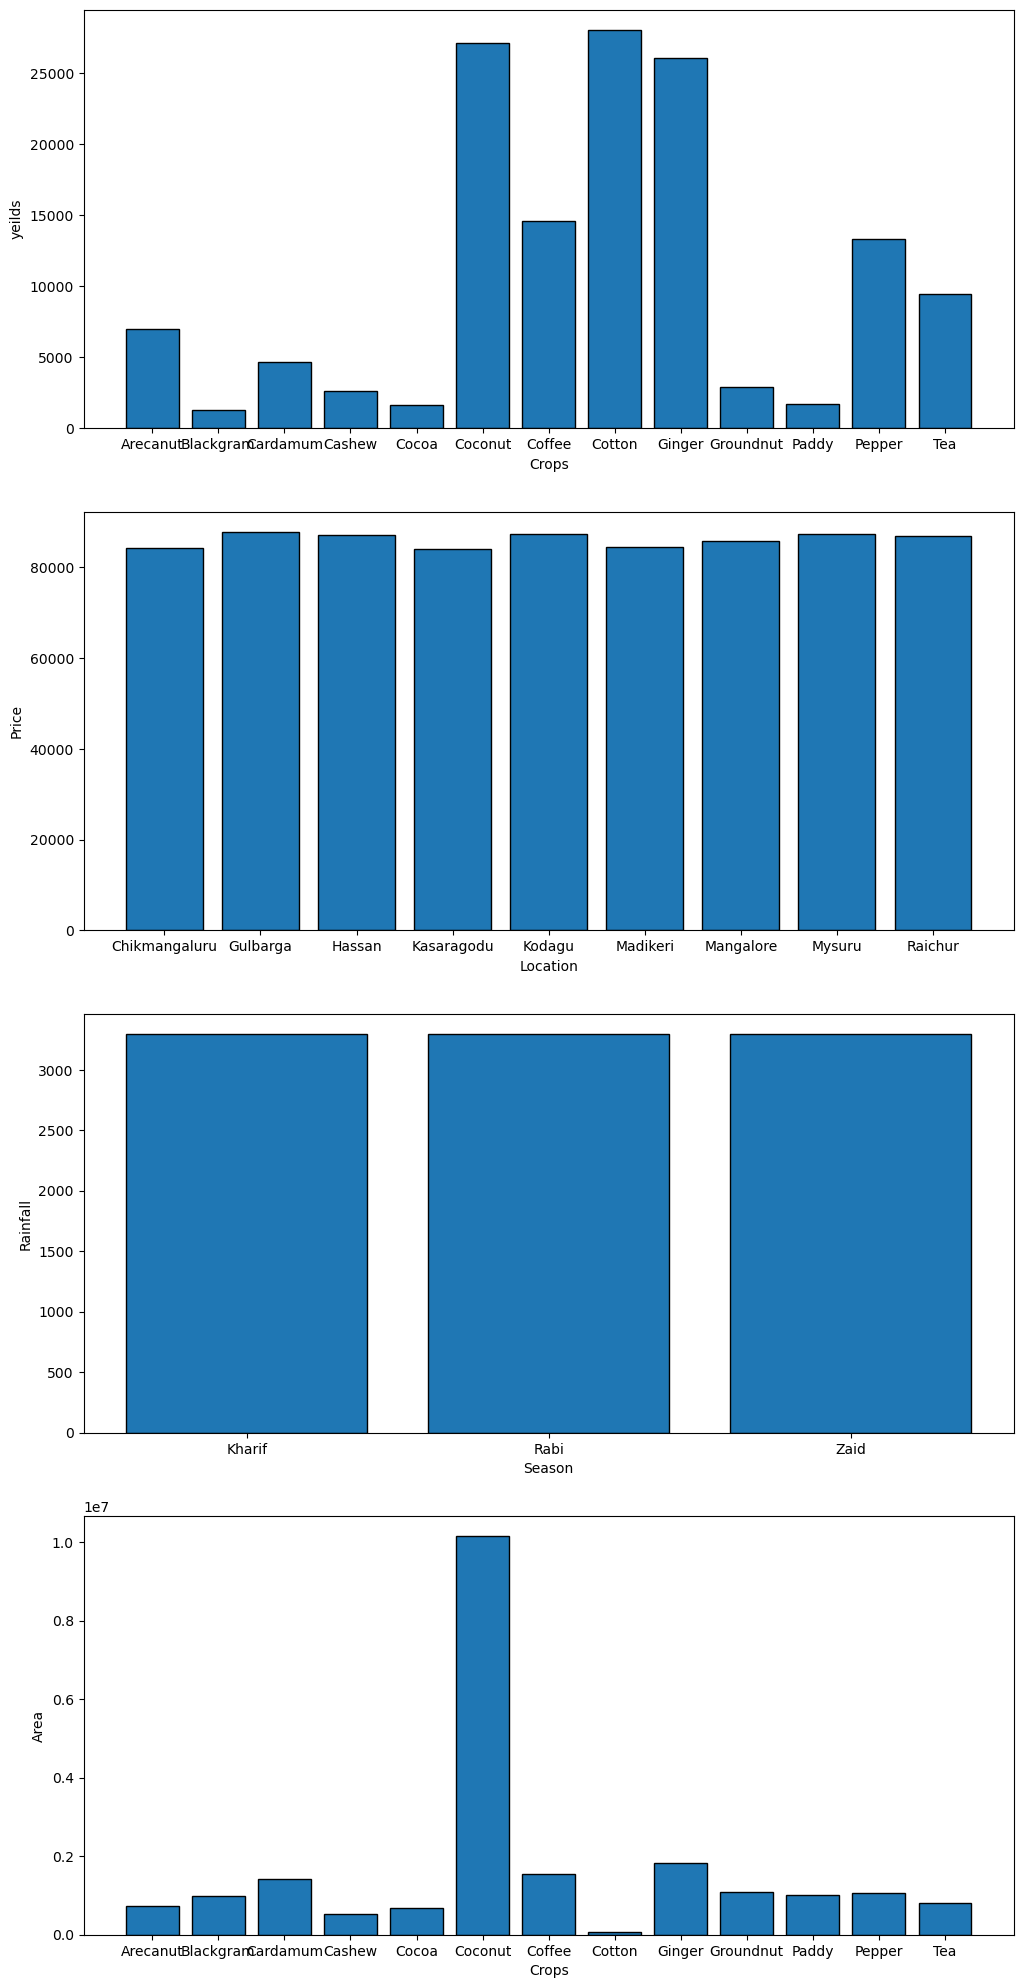

In [13]:
df_yeilds = df.groupby(by="Crops")["yeilds"].mean()
#df_yeilds=pd.DataFrame(df_yeilds)
df_price=df.groupby("Location")["price"].mean()
#df_price=pd.DataFrame(df_price)
df_rainfall=df.groupby("Season")["Rainfall"].median()
#df_rainfall=pd.DataFrame(df_rainfall)
df_crops=df.groupby("Crops")["Area"].sum()
#df_crops=pd.DataFrame(df_crops)

fig,ax=plt.subplots(nrows=4,ncols=1,figsize=(12,25))
ax1=ax[0];ax2=ax[1];ax3=ax[2];ax4=ax[3]

ax1.bar(df_yeilds.index,df_yeilds.values,edgecolor="Black")
ax1.set_xlabel("Crops");ax1.set_ylabel("yeilds")

ax2.bar(df_price.index,df_price.values,edgecolor="Black")
ax2.set_xlabel("Location");ax2.set_ylabel("Price")

ax3.bar(df_rainfall.index,df_rainfall.values,edgecolor="Black")
ax3.set_xlabel("Season");ax3.set_ylabel("Rainfall")

ax4.bar(df_crops.index,df_crops.values,edgecolor="Black")
ax4.set_xlabel("Crops");ax4.set_ylabel("Area");

## 3. Box Plots

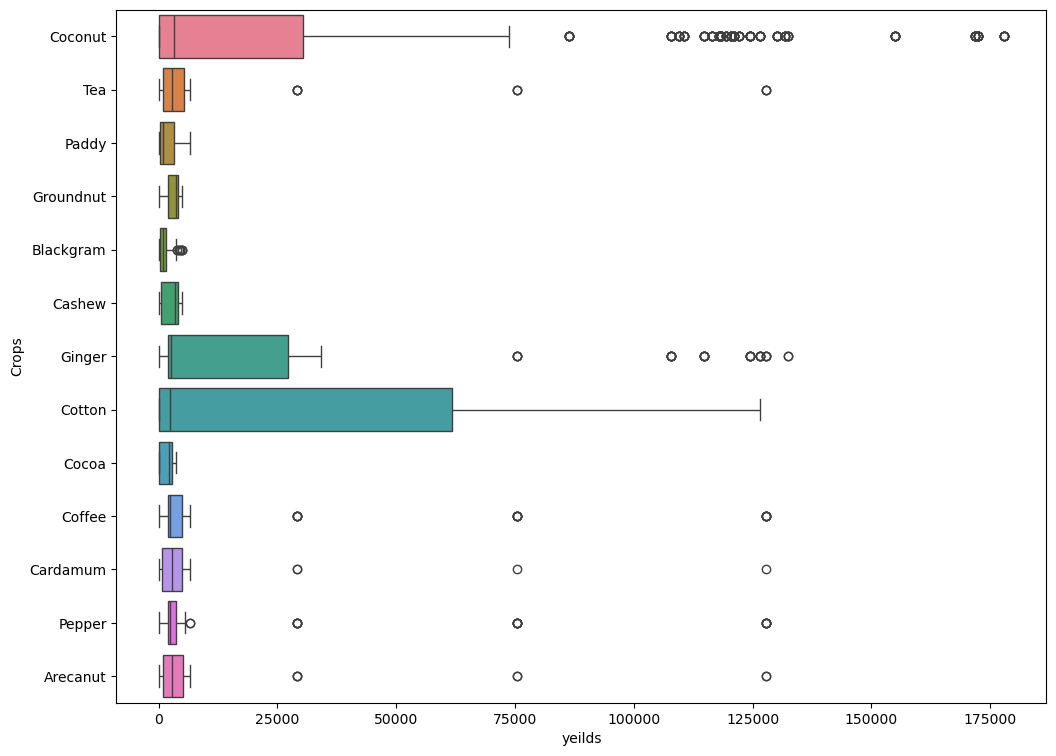

In [38]:
plt.figure(figsize=(12,9))

sns.boxplot(data=df,x="yeilds",y="Crops",hue="Crops");

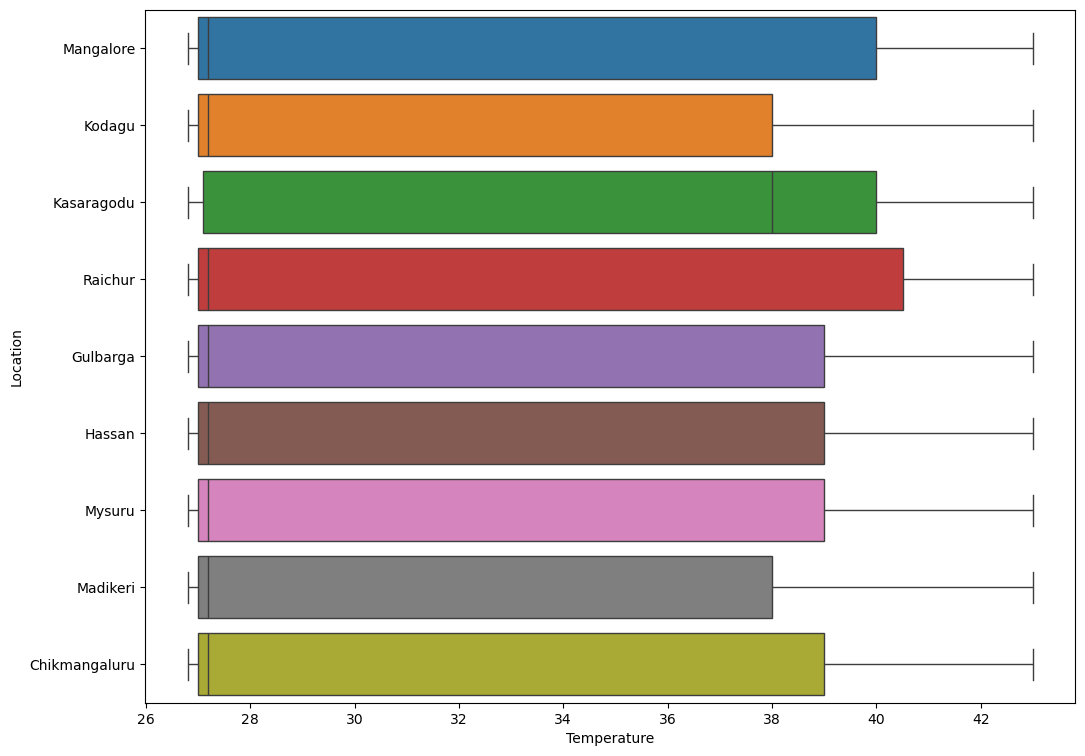

In [39]:
plt.figure(figsize=(12,9))
sns.boxplot(data=df,x="Temperature",y="Location",hue="Location");

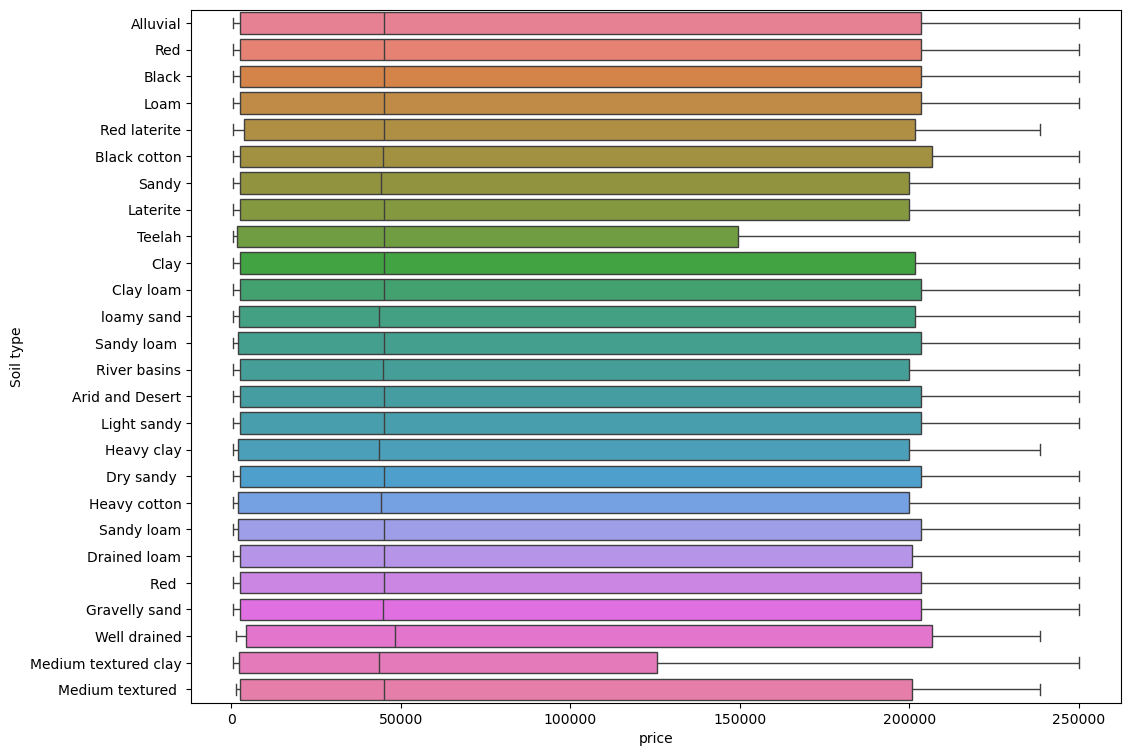

In [40]:
plt.figure(figsize=(12,9))
sns.boxplot(data=df,x="price",y="Soil type",hue="Soil type");

## 4. Scatter Plots

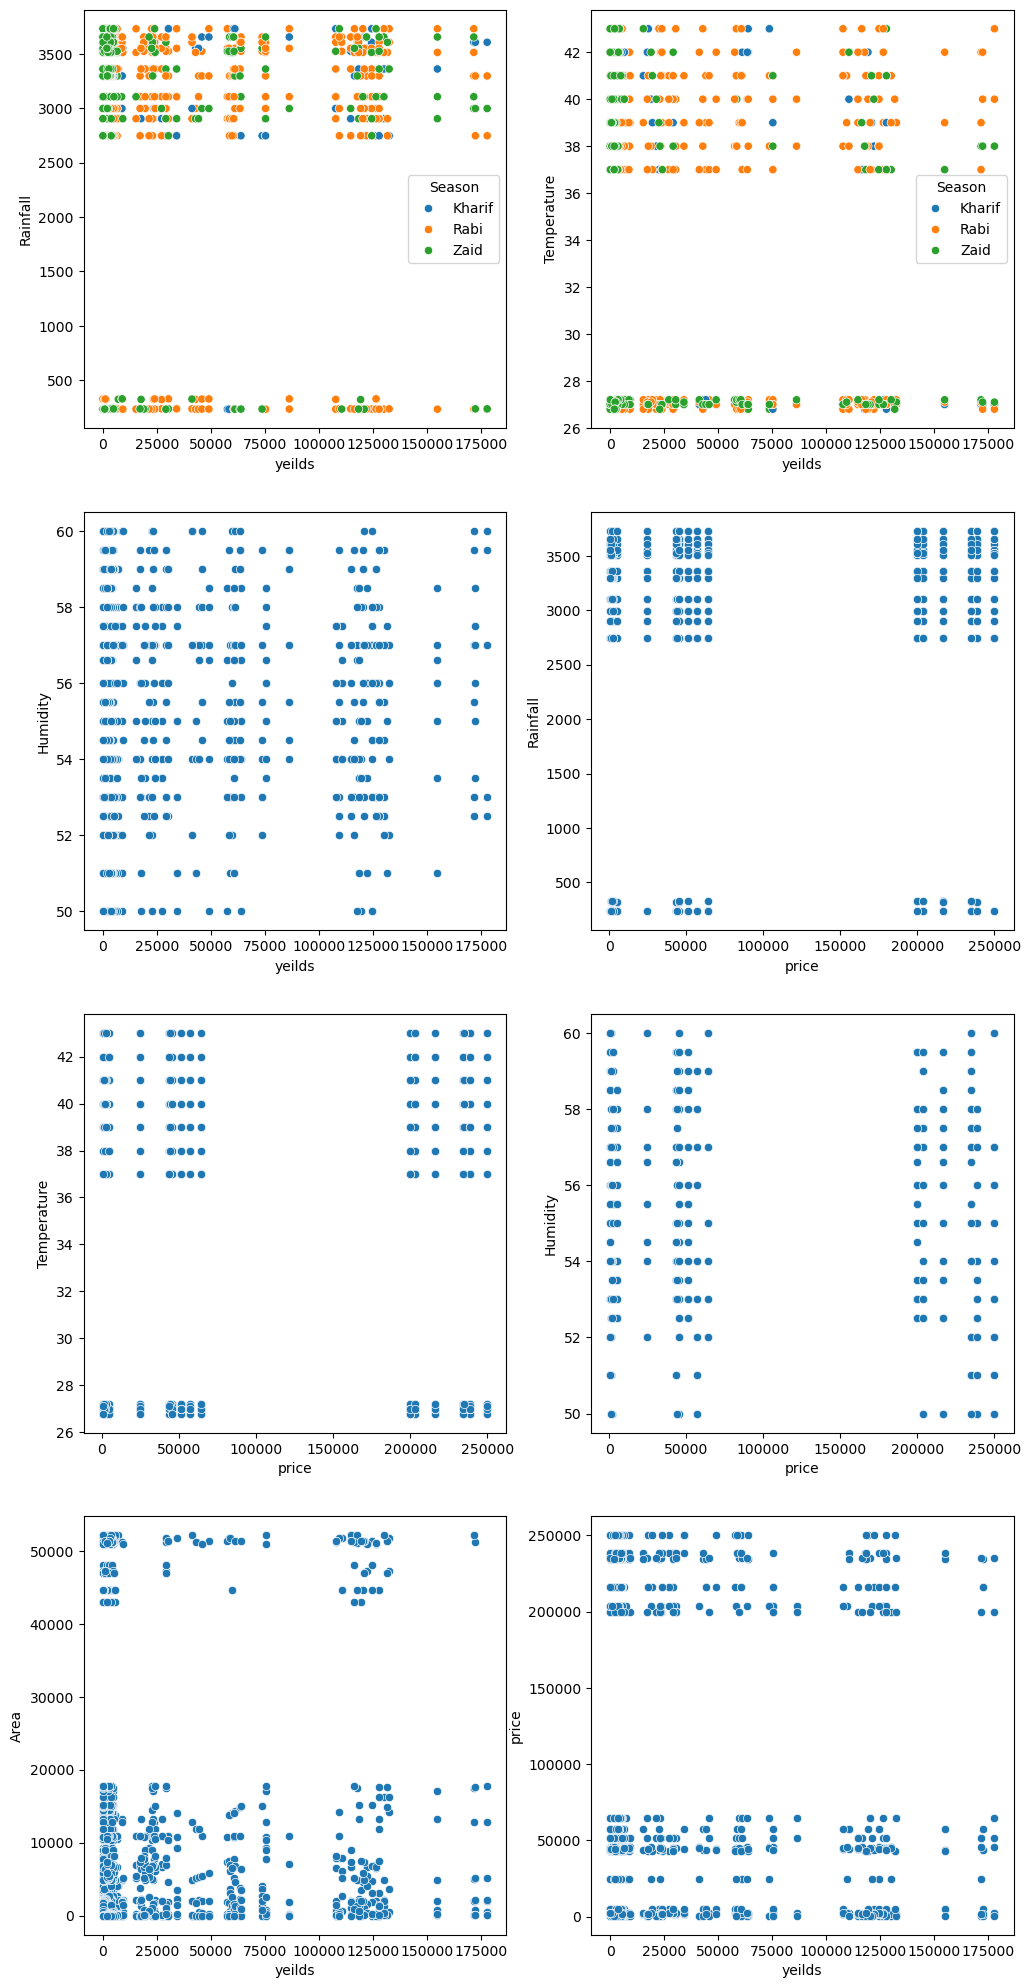

In [14]:
fig,ax=plt.subplots(nrows=4,ncols=2,figsize=(12,25))
ax1=ax[0,0];ax2=ax[0,1];ax3=ax[1,0];ax4=ax[1,1];ax5=ax[2,0];ax6=ax[2,1];ax7=ax[3,0];ax8=ax[3,1]


sns.scatterplot(data=df,y="Rainfall",x="yeilds",hue="Season",ax=ax1)
sns.scatterplot(data=df,y="Temperature",x="yeilds",hue="Season",ax=ax2)
sns.scatterplot(data=df,y="Humidity",x="yeilds",ax=ax3)
sns.scatterplot(data=df,y="Rainfall",x="price",ax=ax4)
sns.scatterplot(data=df,y="Temperature",x="price",ax=ax5)
sns.scatterplot(data=df,y="Humidity",x="price",ax=ax6)
sns.scatterplot(data=df,y="Area",x="yeilds",ax=ax7)
sns.scatterplot(data=df,y="price",x="yeilds",ax=ax8);


## 5. Line Plots

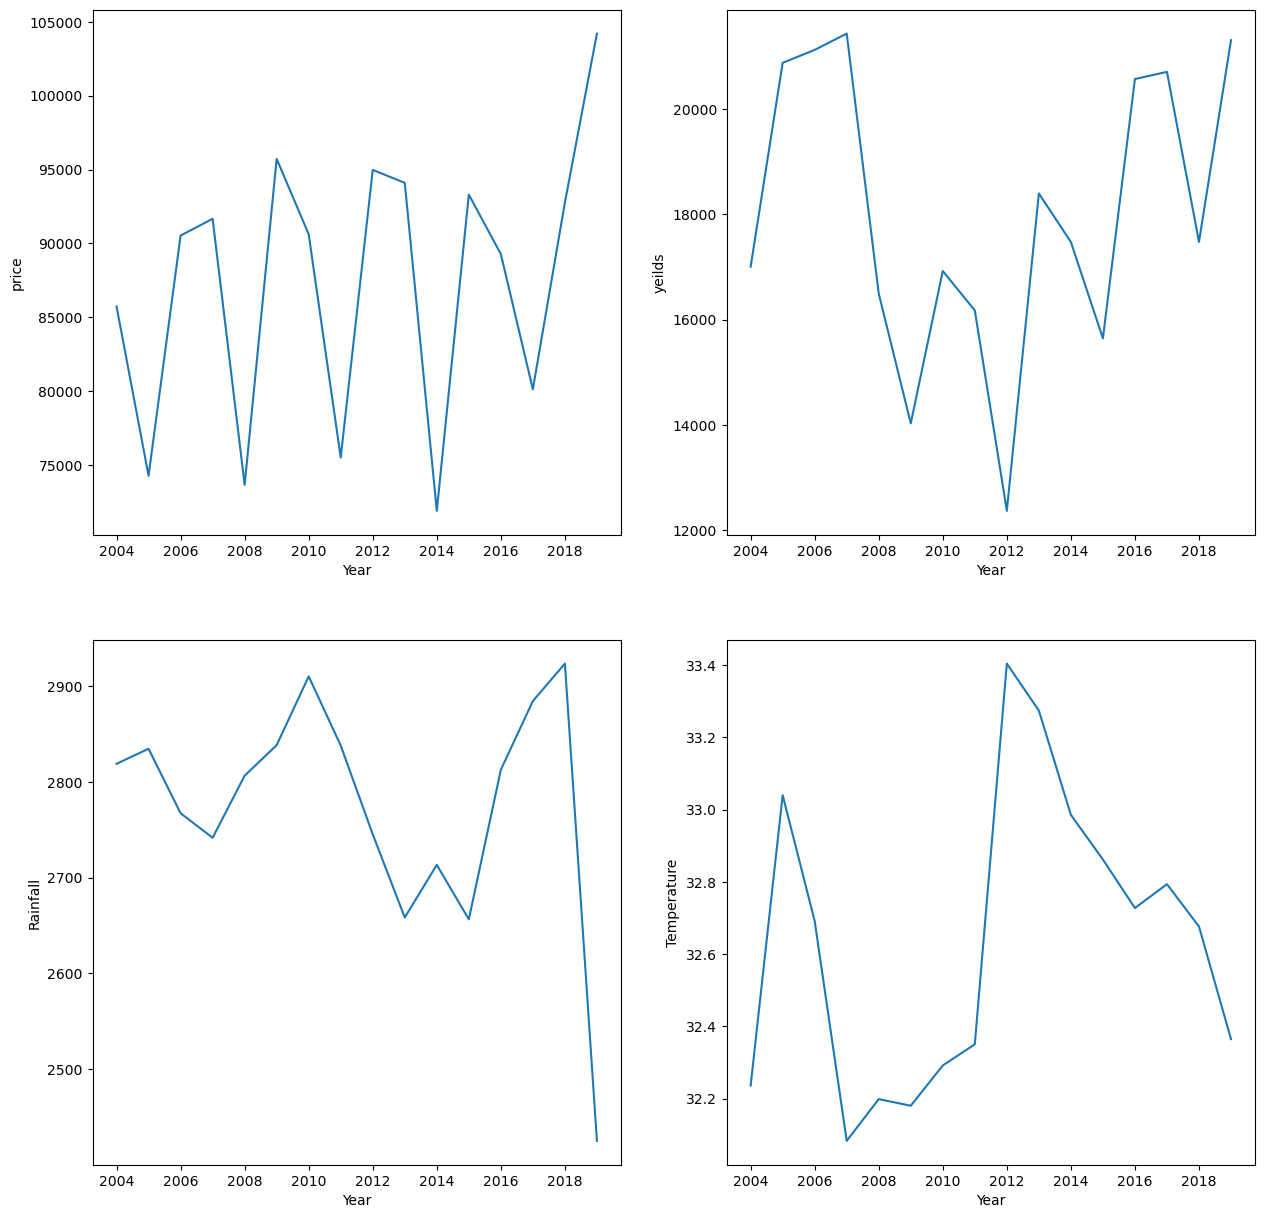

In [15]:
fig,ax=plt.subplots(nrows=2,ncols=2,figsize=(15,15))
ax1=ax[0,0];ax2=ax[0,1];ax3=ax[1,0];ax4=ax[1,1]

df_price = df.groupby("Year")["price"].mean()
df_price=pd.DataFrame(df_price)
sns.lineplot(data=df_price,x="Year",y="price",ax=ax1);

df_yeilds = df.groupby("Year")["yeilds"].mean()
df_yeilds=pd.DataFrame(df_yeilds)
sns.lineplot(data=df_yeilds,x="Year",y="yeilds",ax=ax2);

df_rainfall = df.groupby("Year")["Rainfall"].mean()
df_rainfall=pd.DataFrame(df_rainfall)
sns.lineplot(data=df_rainfall,x="Year",y="Rainfall",ax=ax3);

df_temp = df.groupby("Year")["Temperature"].mean()
df_temp=pd.DataFrame(df_temp)
sns.lineplot(data=df_temp,x="Year",y="Temperature",ax=ax4);


## 6. Bar Charts and Heatmaps

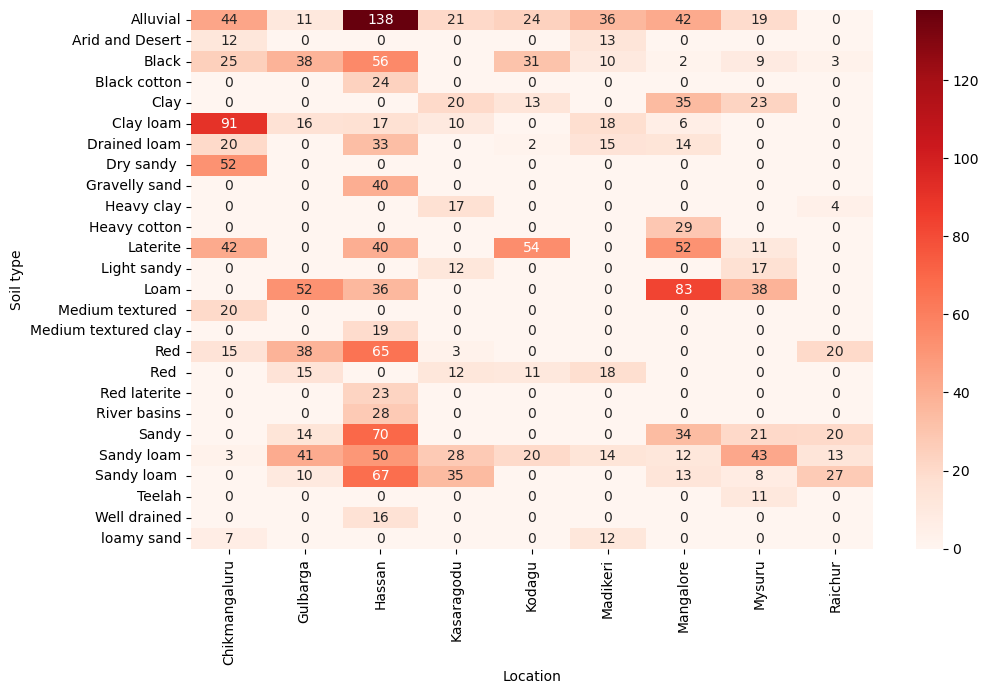

In [16]:
plt.figure(figsize=(11,7))
tabla=pd.crosstab(df["Soil type"],df["Location"])
sns.heatmap(data=tabla,annot=True,fmt="d",cmap="Reds");

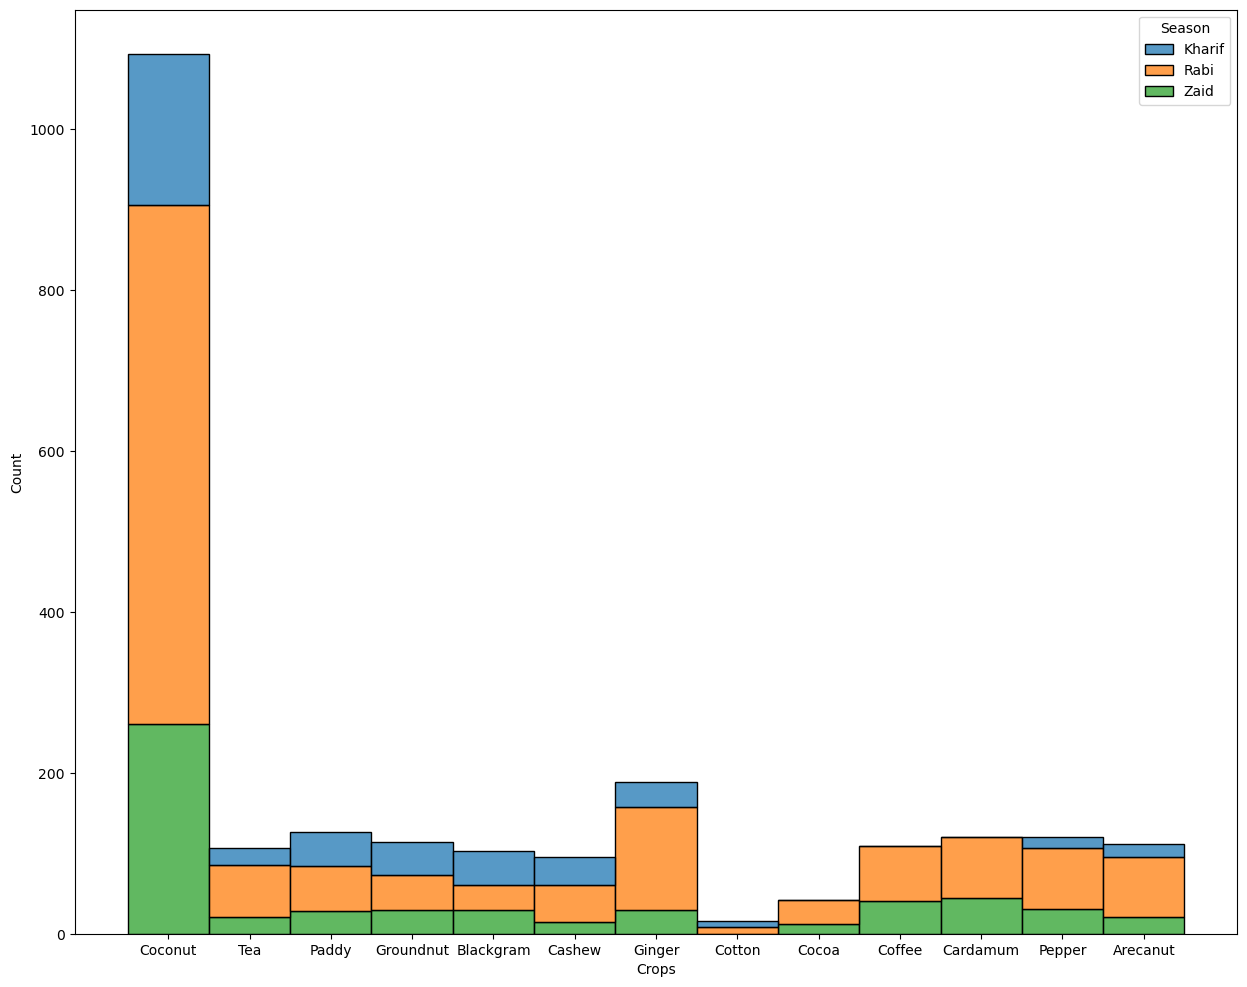

In [17]:
plt.figure(figsize=(15,12))
sns.histplot(data=df, x='Crops', hue='Season',  multiple='stack');


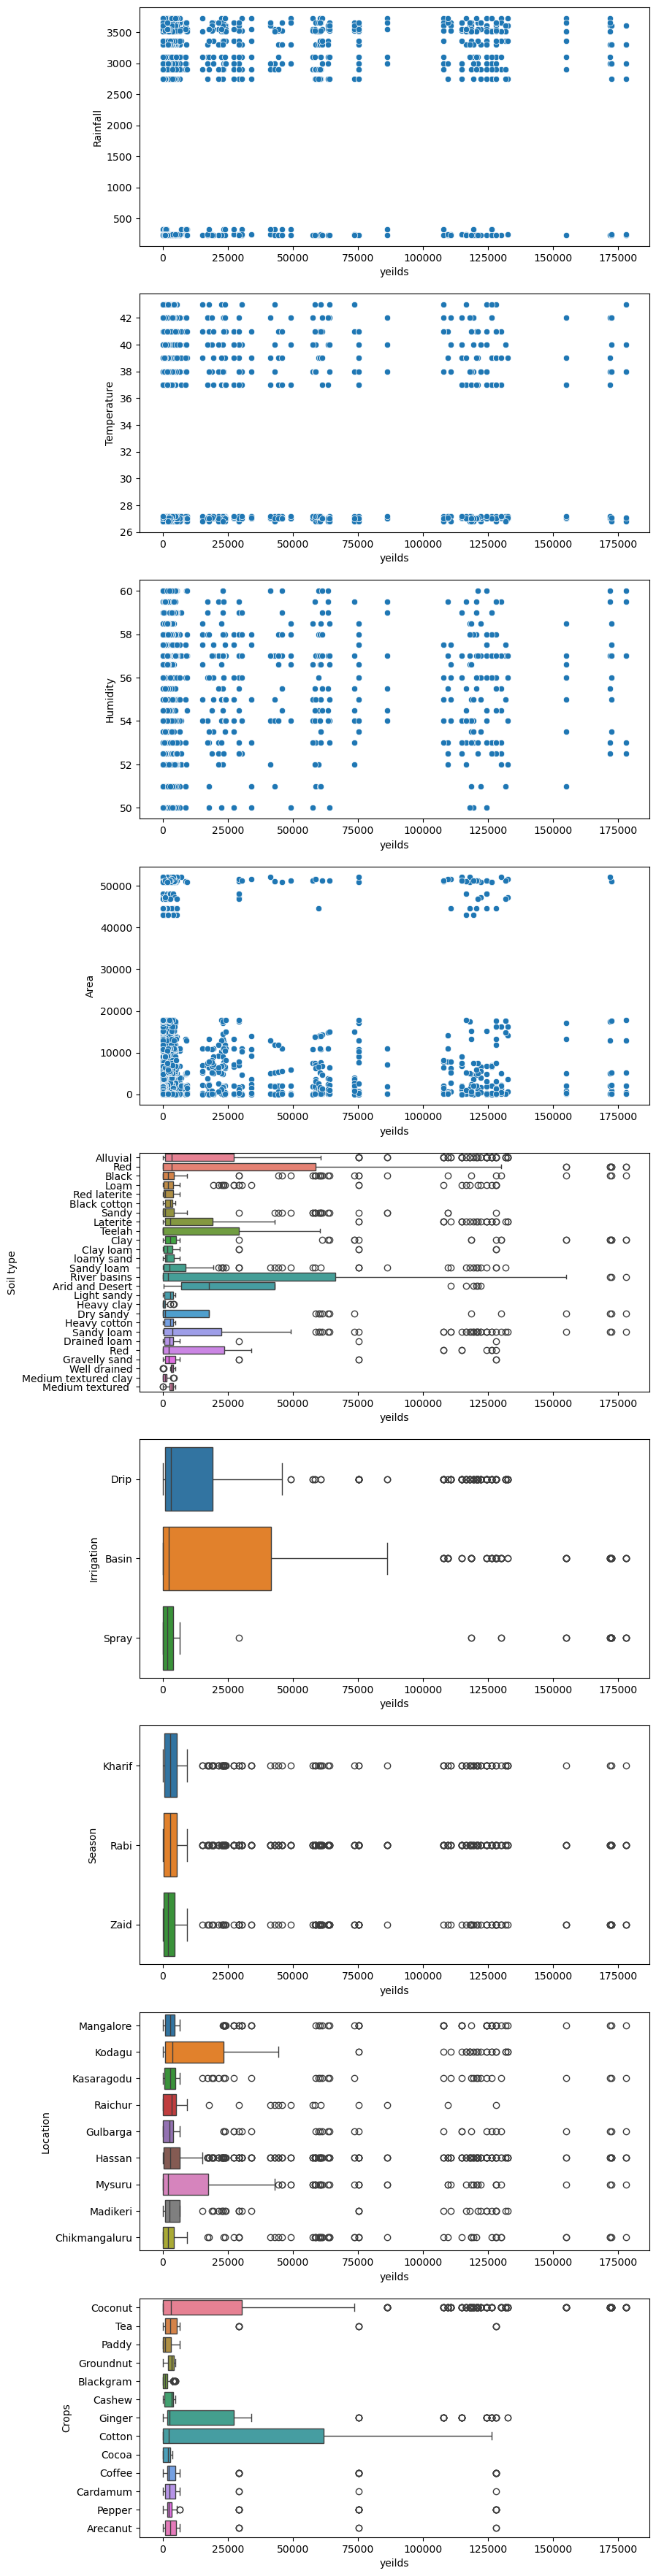

In [45]:
#Looking for more information between performance and different factors such as temperature, humidity, etc.
#Download this chart for later use with AI
fig,ax=plt.subplots(nrows=9,ncols=1,figsize=(9,45))
ax1=ax[0];ax2=ax[1];ax3=ax[2];ax4=ax[3];ax5=ax[4];ax6=ax[5];ax7=ax[6];ax8=ax[7];ax9=ax[8]

sns.scatterplot(data=df,y="Rainfall",x="yeilds",ax=ax1)
sns.scatterplot(data=df,y="Temperature",x="yeilds",ax=ax2)
sns.scatterplot(data=df,y="Humidity",x="yeilds",ax=ax3)
sns.scatterplot(data=df,y="Area",x="yeilds",ax=ax4)
sns.boxplot(data=df,y="Soil type",x="yeilds",hue="Soil type",ax=ax5)
sns.boxplot(data=df,y="Irrigation",x="yeilds",hue="Irrigation",ax=ax6)
sns.boxplot(data=df,y="Season",x="yeilds",hue="Season",ax=ax7)
sns.boxplot(data=df,x="yeilds",y="Location",hue="Location",ax=ax8)
sns.boxplot(data=df,x="yeilds",y="Crops",hue="Crops",ax=ax9);



## Using AI to analyze the graph

In [203]:
df_string= df.to_string()

plantilla = ChatPromptTemplate.from_messages([
    ("system","You are an expert in data science. You provide professional and concise answers, and you are also an expert at solving data analysis problems. You are very skilled at interpreting graphs. For this task, you will be provided with the graph and the dataset containing all the data. Focus on the factors that affect yields, such as temperature, humidity, area, rainfall, soil type,Location,Crops and irrigation systems.Also, please provide a conclusion based on the information provided."),
    ("user",[
        {"type":"text","text":"Interpret the following graph using the dataset {dataframe}. The graph contains multiple charts related to yields and factors that affect them, such as temperature, humidity, area, rainfall, soil type, Location,Crops and irrigation systems. I want you to tell me which factors most influence yield and why, according to the graph and the dataset information. Don't just explain; list the most important factors. For example, in the case of qualitative variables, what were the three most important data points and why did they influence yield? In the case of quantitative variables, tell me the quantity and why this quantity or data point influenced yield."},
        {"type":"image_url","image_url":"https://drive.google.com/uc?export=download&id=1dQFYlcSu-Z1BKGhTZ86uoEJhWJ-fx1pA"}
        
    ])
])
chain = plantilla|llm
respuesta=chain.invoke({"dataframe":df_string})
display(Markdown(respuesta.content))

The analysis of the provided graphs and dataset reveals several key factors influencing crop yields.

**Most Influential Factors on Yields:**

**Qualitative Variables:**

1.  **Crops:**
    *   **Coconut:** Shows the highest median yield and the broadest range of very high yields (extending up to ~175,000 units). This indicates it's a highly productive crop under the prevailing conditions.
    *   **Cotton:** Exhibits the second-highest median yield, with a significant potential for high yields (interquartile range up to ~60,000 units, with outliers reaching higher).
    *   **Ginger:** Displays a notable median yield and a wide spread of yields, including many high values (interquartile range up to ~30,000 units, with outliers reaching higher).

2.  **Soil Type:**
    *   **Alluvial:** Associated with the highest median yields and the widest distribution of high yields, suggesting its superior fertility for the cultivated crops.
    *   **Laterite:** Also supports high median yields and a broad range of high-yielding outcomes, performing similarly to Alluvial soil.
    *   **Red:** Demonstrates a good median yield and a wide spread, indicating its general suitability for various crops, including those with high yield potential.

3.  **Irrigation System:**
    *   **Drip:** Shows the highest median yield and the widest range of high yields, highlighting its efficiency in water and nutrient delivery for optimal crop growth.
    *   **Basin:** Exhibits a moderate median yield and a good range of yields, performing better than 'Spray' but less effectively than 'Drip'.
    *   **Spray:** Has the lowest median yield and a narrower range, suggesting it is less efficient or suitable for maximizing yields in this dataset.

4.  **Season:**
    *   **Kharif:** Characterized by the highest median yields and the widest distribution of high yields, indicating optimal climatic conditions for crop growth during this period.
    *   **Rabi:** Shows moderate median yields and a good range of yields, performing reasonably well but generally not reaching the peak yields seen in Kharif.
    *   **Zaid:** Exhibits the lowest median yield and a narrower range, suggesting less favorable conditions for maximizing yields.

5.  **Location:**
    *   **Mangalore:** Displays the highest median yield and a wide spread of high yields, indicating highly favorable local conditions for agriculture.
    *   **Kodagu:** Also shows high median yields and a broad range of high-yielding outcomes, similar to Mangalore.
    *   **Hassan:** Demonstrates a good median yield and a wide spread, indicating its suitability for various crops and supporting high yields.

**Quantitative Variables:**

1.  **Area:**
    *   **Quantity:** A strong positive correlation is observed, where **larger areas (especially above 40,000 units)** are consistently associated with higher absolute yields. This is a direct relationship, as more land cultivated naturally leads to more produce.

2.  **Rainfall:**
    *   **Quantity:** Rainfall in the range of **2700-3700 units** is most influential, as it is associated with the highest concentration of high yields. While some high yields occur at very low rainfall (around 200-300 units), this is likely compensated by irrigation, making the higher natural rainfall range optimal for overall high productivity.

3.  **Temperature:**
    *   **Quantity:** A temperature range of **27-28°C** is highly influential, as it is associated with the highest observed yields and a wider distribution of high-yielding data points. Although higher temperatures (37-43°C) also produce good yields, the peak performance is clearly seen in the lower range.

4.  **Humidity:**
    *   **Quantity:** Humidity levels between **50-60%** show a wide distribution of yields without a clear pattern. This suggests that within this range, humidity is **less influential** as a primary factor differentiating high from low yields compared to other environmental and agricultural inputs.

**Conclusion:**

The analysis clearly indicates that **Crop type, Soil type, Irrigation System, Season, and Location** are highly influential qualitative factors, with specific categories within each showing superior yield performance. Among quantitative factors, **Area** has a direct positive correlation with yield, while optimal **Rainfall (2700-3700 units)** and **Temperature (27-28°C)** ranges are crucial for maximizing productivity. Humidity, within the observed range, appears to have a less pronounced direct impact on yield variation. Effective agricultural planning should prioritize selecting suitable crops for specific soil types, locations, and seasons, complemented by efficient irrigation systems, to achieve optimal yields.

## Price vs diferents parameters

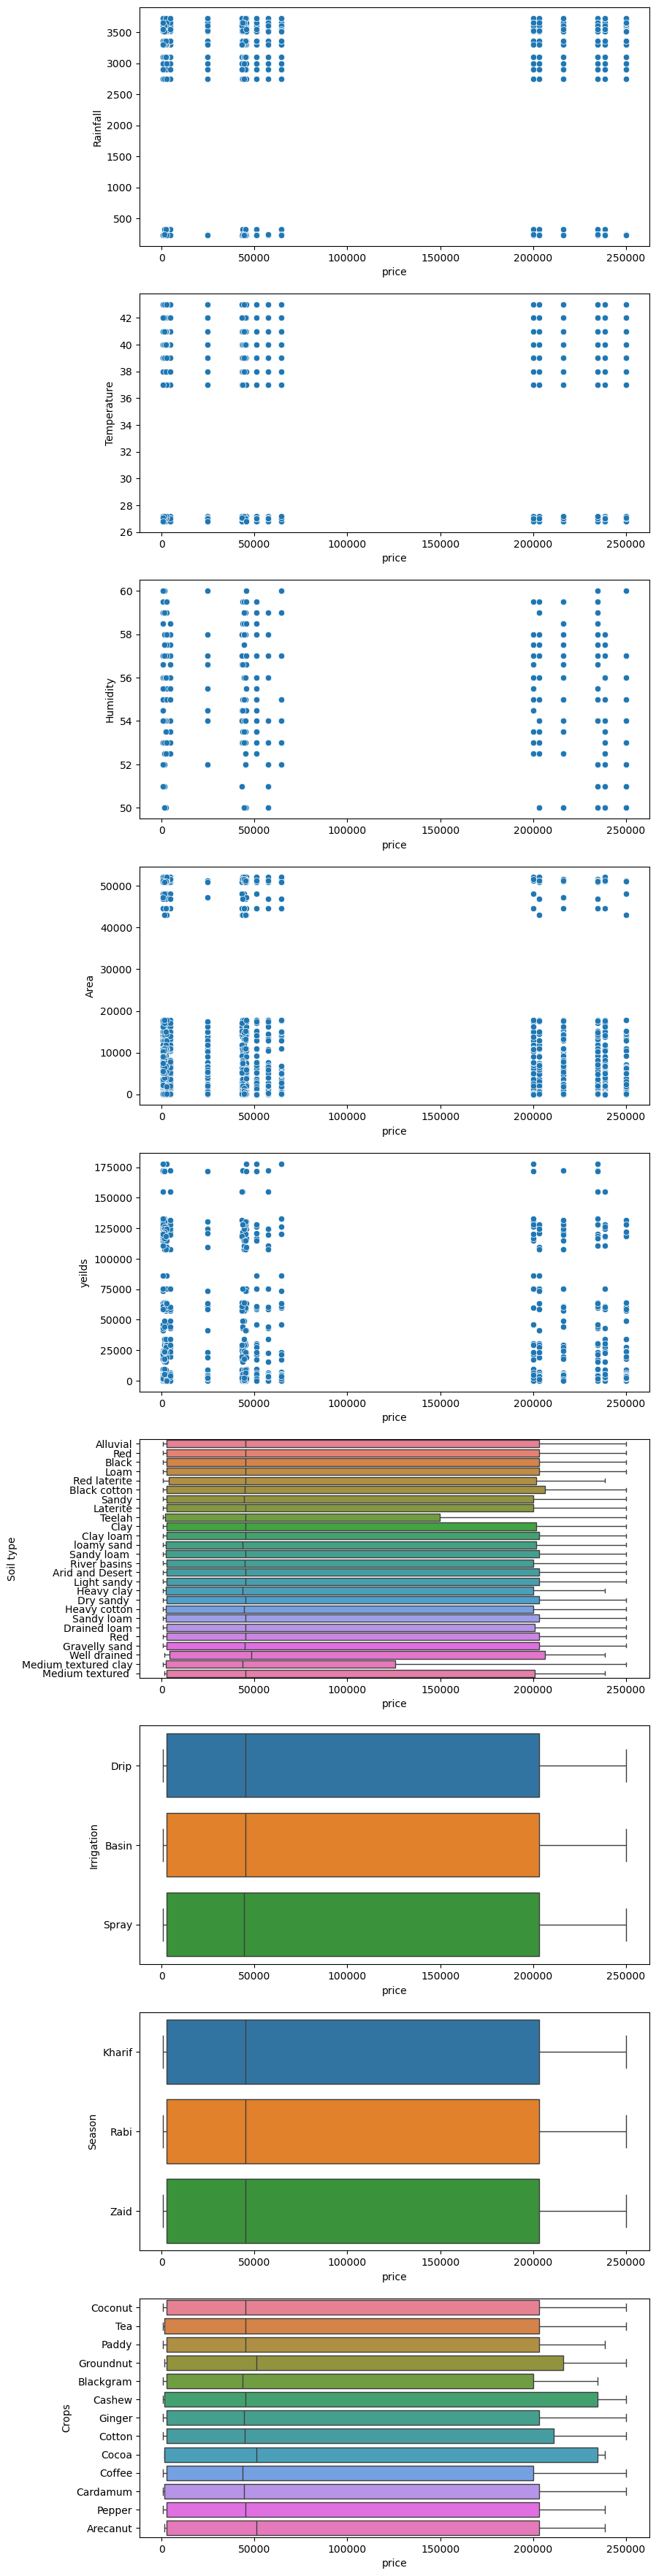

In [46]:
fig,ax=plt.subplots(nrows=9,ncols=1,figsize=(9,45))
ax1=ax[0];ax2=ax[1];ax3=ax[2];ax4=ax[3];ax5=ax[4];ax6=ax[5];ax7=ax[6];ax8=ax[7];ax9=ax[8]

sns.scatterplot(data=df,y="Rainfall",x="price",ax=ax1)
sns.scatterplot(data=df,y="Temperature",x="price",ax=ax2)
sns.scatterplot(data=df,y="Humidity",x="price",ax=ax3)
sns.scatterplot(data=df,y="Area",x="price",ax=ax4)
sns.scatterplot(data=df,x="price",y="yeilds",ax=ax5)
sns.boxplot(data=df,y="Soil type",x="price",hue="Soil type",ax=ax6)
sns.boxplot(data=df,y="Irrigation",x="price",hue="Irrigation",ax=ax7)
sns.boxplot(data=df,y="Season",x="price",hue="Season",ax=ax8)
sns.boxplot(data=df,x="price",y="Crops",hue="Crops",ax=ax9);


In [133]:
df_string= df.to_string()

plantilla = ChatPromptTemplate.from_messages([
    ("system","You are an expert in data science. You provide professional and concise answers, and you are also an expert at solving data analysis problems. You are very skilled at interpreting graphs. For this task, you will be provided with the graph and the dataset containing all the data. Focus on the factors that affect price, such as temperature, humidity, area, rainfall, soil type, Crops and irrigation systems. Also, please provide a conclusion based on the information provided."),
    ("user",[
        {"type":"text","text":"Interpret the following graph using the dataset {dataframe}. The graph contains multiple charts related to price and factors that affect them, such as temperature, humidity, area, Crops,rainfall, soil type and irrigation systems. I want you to tell me which factors most influence price and why, according to the graph and the dataset information. Don't just explain; list the most important factors. For example, in the case of qualitative variables, what were the three most important data points and why did they influence price? In the case of quantitative variables, tell me the quantity and why this quantity or data point influenced price."},
        {"type":"image_url","image_url":"https://drive.google.com/uc?export=download&id=1CyalnN1s8HuROIKka_77Ox2GZt3Ku7vX"}
        
       
    ])
])
chain = plantilla|llm
respuesta=chain.invoke({"dataframe":df_string})
display(Markdown(respuesta.content))

The analysis of the provided graphs and dataset reveals several factors that influence crop prices.

**Most Influential Factors:**

1.  **Crops (Qualitative Variable):** This is the most significant factor, showing distinct price distributions.
    *   **Cardamom:** Exhibits the highest median price, consistently around **200,000**, indicating it is a high-value crop.
    *   **Pepper:** Also shows a high median price, consistently around **200,000**, similar to Cardamom.
    *   **Tea:** Commands a high median price, consistently around **200,000**, making it another top-tier crop in terms of value.
    *   *Why:* These crops consistently fetch significantly higher prices compared to others like Coconut, Paddy, or Groundnut, which have median prices mostly below 50,000. This suggests they are specialty or high-demand commodities.

2.  **Yields (Quantitative Variable):** There is a strong inverse relationship between yields and price.
    *   **Very Low Yields (below ~5,000 units):** These are strongly associated with the **highest prices (200,000 - 250,000)**.
    *   *Why:* This indicates that crops fetching the highest prices (e.g., Cardamom, Pepper, Tea) often have lower yields per unit area, or are grown in smaller, specialized plots, but their high unit value translates to significant overall revenue. Conversely, high yields generally correspond to lower prices.

3.  **Soil Type (Qualitative Variable):** Certain soil types are strongly correlated with higher prices.
    *   **Red laterite:** Shows a consistently high median price (around **200,000**), suggesting its suitability for high-value crops.
    *   **Gravelly sand:** Also has a high median price (around **200,000**).
    *   **Well drained:** Displays a high median price (around **200,000**).
    *   *Why:* These soil types provide optimal conditions for the cultivation of high-value crops, leading to better quality or higher market demand.

4.  **Area (Quantitative Variable):** While high prices are observed across various area ranges, there's a notable pattern.
    *   **Smaller Areas (e.g., below ~5,000 units):** These areas are predominantly associated with the **highest prices (200,000 - 250,000)**.
    *   *Why:* This suggests that high-value crops are often cultivated in smaller, more intensively managed plots, where the focus is on quality and yield per plant rather than sheer volume from vast areas.

**Factors with Less or No Clear Influence:**

*   **Rainfall, Temperature, and Humidity:** The scatter plots for these environmental factors do not show a clear linear correlation or distinct clustering of high prices at specific ranges. Both low and high values for these variables are associated with the full spectrum of prices (low to high). This indicates that while these factors are essential for agriculture, their variation within this dataset does not singularly dictate higher or lower prices.
*   **Irrigation Systems (Drip, Basin, Spray):** All three irrigation methods show very similar median prices (around 40,000-50,000) and broad price distributions. This suggests that the specific type of irrigation system used does not significantly differentiate crop prices in this dataset.
*   **Season (Kharif, Rabi, Zaid):** The box plots for seasons display highly similar median prices and price ranges, indicating that the season of cultivation does not have a strong independent influence on crop price in this dataset.

**Conclusion:**

The most influential factors determining crop price in this dataset are **the type of crop cultivated (e.g., Cardamom, Pepper, Tea), the resulting yields (with lower yields often correlating with higher prices due to high unit value), and the soil type (Red laterite, Gravelly sand, Well drained being favorable).** Smaller cultivation areas also tend to be associated with higher-priced outputs, likely due to the nature of high-value crops. Environmental factors like rainfall, temperature, and humidity, along with the irrigation system and season, appear to be less direct drivers of price variation, possibly acting as underlying conditions rather than primary differentiators of market value.

## Conclusion
The analysis reveals that Area and Yields are the most critical quantitative factors influencing crop price, demonstrating a strong inverse relationship where smaller areas and lower yields correlate with higher prices. Among qualitative factors, various Soil Types (e.g., Alluvial, Red, Laterite) and Irrigation Systems (especially Drip and Basin) are consistently associated with high-value crops. Environmental conditions like Temperature, Humidity, Rainfall, and the Season appear to be permissive for cultivation but do not directly drive the magnitude of crop prices as significantly as the cultivation scale and productivity do. This suggests that market value is more tied to the scarcity, specialization, or inherent value of crops that may require specific growing conditions (soil, irrigation) and are produced in limited quantities.

# Determining the best machine learning model for the dataset

In [199]:
df_string= df.to_string()
plantilla = ChatPromptTemplate.from_messages([
    ("system","You are an expert in data science. You provide professional and concise answers, and you are also skilled at solving data analysis problems. You are very adept at recommending machine learning models. For this task, you will be provided with the dataset and will recommend the best machine learning model for price and yeilds variables."),
    ("user","You will recommend a machine learning model using the dataset {dataframe}. I want you to tell me what machine learning model is the best for price and yeild variable. Also thell me if it´s ok to use random forest model, random treemodel, decision tree model, linear regresion model, logistic regression model or is better option use other model.")
])
chain = plantilla|llm
respuesta=chain.invoke({"dataframe":df_string})
display(Markdown(respuesta.content))

Based on the dataset provided, predicting 'price' and 'yields' involves estimating continuous numerical values, which classifies this as a **regression problem**.

Let's evaluate the models you suggested and recommend the best options:

1.  **Linear Regression:**
    *   **Suitability:** Potentially viable, but it assumes a linear relationship between features and the target. Given the diverse factors like `Soil type`, `Crops`, `Rainfall`, and `Temperature`, the relationships are likely complex and non-linear. It would require extensive feature engineering (e.g., one-hot encoding for categorical variables) and might not capture intricate interactions.
    *   **Recommendation:** A good baseline for simple relationships, but likely suboptimal for this dataset's complexity.

2.  **Logistic Regression:**
    *   **Suitability:** **Not suitable.** Logistic Regression is a classification algorithm used for predicting binary or multi-class categorical outcomes, not continuous numerical values like price or yields.

3.  **Decision Tree Model:**
    *   **Suitability:** A good starting point for regression tasks. Decision trees can capture non-linear relationships and handle mixed data types (numerical and categorical, after appropriate encoding).
    *   **Recommendation:** Better than linear regression for non-linearities, but prone to overfitting and instability.

4.  **Random Tree Model:**
    *   **Clarification:** "Random Tree" typically refers to a single decision tree where some randomness is introduced during its construction (e.g., random feature selection at splits), or it can be a component of a Random Forest. Its characteristics are generally similar to a Decision Tree, with slight improvements in robustness if randomness is implied.
    *   **Recommendation:** Similar to a Decision Tree, it serves as a foundational model but has limitations.

5.  **Random Forest Model:**
    *   **Suitability:** **Highly recommended.** Random Forest is an ensemble method that builds multiple decision trees and averages their predictions. This significantly reduces overfitting, improves robustness, and effectively handles non-linear relationships, interactions between features, and mixed data types. It also provides feature importance, which can be valuable for understanding the drivers of price and yields.
    *   **Recommendation:** An excellent choice for this problem, offering a strong balance of performance and generalization.

### Best Machine Learning Model Recommendations:

For predicting 'price' and 'yields', which are continuous variables, the best models are generally **ensemble tree-based models** due to their ability to handle complex, non-linear relationships and diverse feature types:

1.  **Random Forest Regressor:**
    *   **Why:** It's robust, less prone to overfitting than single decision trees, handles multicollinearity well, and can manage a mix of numerical and categorical features (after proper encoding, such as one-hot encoding for `Location`, `Soil type`, `Irrigation`, `Crops`, `Season`). It's a strong and reliable performer.

2.  **Gradient Boosting Regressors (e.g., XGBoost, LightGBM, CatBoost):**
    *   **Why:** These models often achieve state-of-the-art performance on tabular data. They build trees sequentially, with each new tree correcting errors of the previous ones.
        *   **XGBoost/LightGBM:** Known for high accuracy and speed. They require careful hyperparameter tuning.
        *   **CatBoost:** Particularly strong with categorical features, as it has built-in mechanisms to handle them efficiently without explicit one-hot encoding, which can be advantageous given the high cardinality of `Soil type` and `Crops`.
    *   **Recommendation:** If maximizing predictive accuracy is the primary goal, Gradient Boosting models are likely to outperform Random Forest, but they might require more computational resources and hyperparameter tuning.

### Preprocessing Steps (Crucial for all models):

Regardless of the chosen model, the following preprocessing steps will be essential:

*   **Handle Missing Values:** Inspect the dataset for any missing values and decide on an appropriate imputation strategy (e.g., mean, median for numerical; mode for categorical).
*   **Encode Categorical Features:** Convert categorical variables (`Location`, `Soil type`, `Irrigation`, `Crops`, `Season`) into a numerical format. One-hot encoding is a common choice for tree-based models, while CatBoost can handle them directly.
*   **Feature Scaling (Optional but Recommended for some models):** For models like Linear Regression or SVR (if considered), numerical features (`Year`, `Area`, `Rainfall`, `Temperature`, `Humidity`) should be scaled (e.g., Standardization or Min-Max Scaling). Tree-based models are generally less sensitive to feature scaling.

In summary, while Random Forest is a solid choice, for potentially higher accuracy, consider **XGBoost, LightGBM, or CatBoost** as better options. Logistic Regression is entirely inappropriate for this regression task.

## Random Forest 

### Predicting crop yield behavior

In [41]:
enc = OrdinalEncoder()
df_encoding=df.copy()
df_encoding[["Irrigation","Soil type","Season","Location","Crops","Location"]] = enc.fit_transform(df_encoding[["Irrigation","Soil type","Season","Location","Crops","Location"]])
scale = MinMaxScaler()
df_encoding[["Area","price","Humidity","Temperature","Rainfall"]]= scale.fit_transform(df_encoding[["Area","price","Humidity","Temperature","Rainfall"]])
df_encoding

,Year,Location,Area,Rainfall,Temperature,Soil type,Irrigation,yeilds,Humidity,Crops,price,Season
0,2004,6.0,0.024521,0.763584,0.012346,0.0,1.0,2570.0,0.70,5.0,0.799560,0.0
1,2004,6.0,0.254845,0.763584,0.012346,0.0,1.0,27170.0,0.75,5.0,0.016885,0.0
2,2004,6.0,1.000000,0.763584,0.012346,0.0,1.0,114744.0,0.70,5.0,0.202943,0.0
3,2004,6.0,0.013892,0.790323,0.012346,0.0,1.0,1402.0,0.50,5.0,0.865317,0.0
4,2004,6.0,0.247208,0.790323,0.012346,0.0,1.0,23456.0,0.60,5.0,0.008049,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
3045,2017,3.0,0.000307,0.763584,0.938272,0.0,0.0,3830.0,0.50,0.0,0.016885,2.0
3046,2018,3.0,0.000038,0.763584,0.938272,0.0,0.0,4.0,0.60,0.0,0.202943,2.0
3047,2004,3.0,0.000153,0.763584,0.938272,0.0,0.0,9.0,0.40,0.0,0.865317,2.0
3048,2005,3.0,0.000384,0.790323,1.000000,0.0,0.0,12.0,0.80,0.0,0.008049,2.0


In [22]:
features = ["Area","Soil type","Irrigation","Season","Crops","Location","Humidity","Temperature","Rainfall"]
X=df_encoding[features]
y=df_encoding["yeilds"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=20)
rf_model=RandomForestRegressor(n_estimators=100,max_depth=None,random_state=42)
rf_model.fit(X_train,y_train)
y_pred=rf_model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 938060947.540978
MAE: 16940.92304431818
R2: 0.3184592588544043


### Conclusion of the machine learning model

The model is unreliable and it was not possible to predict the behavior of yields as well as the variables that most influence it.

## KMeans and PCA

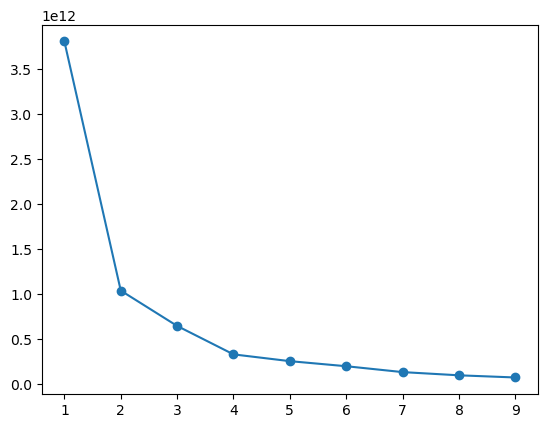

In [26]:
inertias = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_normalizado)
    inertias.append(km.inertia_)
plt.plot(range(1, 10), inertias, marker='o');

In [24]:
df_normalizado = df.loc[:,["Rainfall","Area","yeilds","Temperature","Humidity","Year"]]
escalado = MinMaxScaler()
X_normalizado=escalado.fit_transform(df_normalizado)
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_normalizado)
kmeans=KMeans(n_clusters=2,random_state=42)
clusters=kmeans.fit_predict(X_pca)

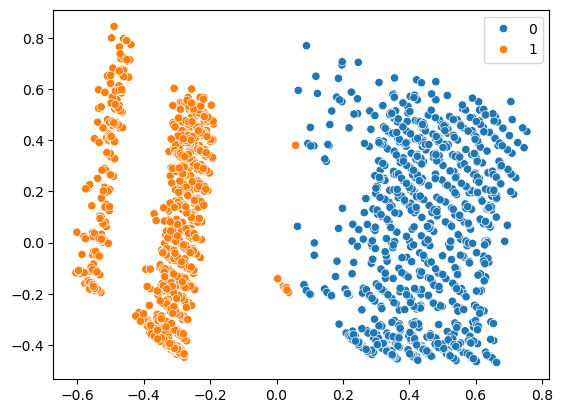

In [44]:
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1],hue=clusters);

In [42]:
df_string= df.to_string()

plantilla = ChatPromptTemplate.from_messages([
    ("system","You are an expert in data science. You provide professional and concise answers, and you are also skilled at solving data analysis problems. You are very adept at interpreting graphs. For this task, you will be provided with the graph and the dataset containing all the data. The KMeans graph was created using the variables Rainfall, Temperature, Yields, Humidity, and Area. Interpret the graph based on the information provided. Furthermore, provide a conclusion based on the information provided."),
    ("user",[
        {"type":"text","text":"Interpret the following graph using the dataset {dataframe}. The graph contains two data sets, as specified by the dataset number. I would like your interpretation of the graph and what it indicates. To help you, I will provide the following code with which the graph was created:df_normalized = df.loc[:,['Rainfall','Area','yields','Temperature','Humidity','Year']];scaled = MinMaxScaler();X_normalized=scaled.fit_transform(df_normalized);pca=PCA(n_components=2);X_pca=pca.fit_transform(X_normalized);kmeans=KMeans(n_clusters=2,random_state=42);clusters=kmeans.fit_predict(X_pca);sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1],hue=clusters);"},
        {"type":"image_url","image_url":"https://drive.google.com/uc?export=download&id=1lDan8KNBJjvJSaU458X7fLJMJnh0BFN4"}
        
    ])
])
chain = plantilla|llm
respuesta=chain.invoke({"dataframe":df_string})
display(Markdown(respuesta.content))

The graph displays the results of a K-Means clustering algorithm applied to a dataset after dimensionality reduction using Principal Component Analysis (PCA). The clustering was performed on normalized data from the 'Rainfall', 'Area', 'yields', 'Temperature', 'Humidity', and 'Year' variables.

**Interpretation:**

The scatter plot clearly shows two distinct clusters, labeled '0' (blue) and '1' (orange), based on the first two principal components (PC1 on the x-axis, PC2 on the y-axis):

*   **Cluster 0 (Blue):** This cluster is predominantly located on the right side of the plot, indicating generally higher values along the first principal component. It appears more spread out, suggesting a wider range of combined characteristics among its data points.
*   **Cluster 1 (Orange):** This cluster is concentrated on the left side of the plot, with lower values along the first principal component. It exhibits a more structured pattern, appearing as two vertical "bands" or dense columns. This suggests that data points within this cluster share more specific or constrained ranges of characteristics, particularly along the second principal component, for distinct values of the first principal component.

The clear visual separation between the two clusters, primarily along the first principal component, indicates that the K-Means algorithm successfully identified two distinct groupings within the data based on the chosen features.

**Conclusion:**

The analysis reveals that the agricultural and environmental data, encompassing Rainfall, Area, Yields, Temperature, Humidity, and Year, naturally segregates into two distinct segments. These segments represent two fundamentally different profiles of observations within the dataset. To fully understand the practical implications, further investigation into the specific characteristics (mean values or distributions of the original features) of each cluster and the loadings of the principal components would be required to describe what differentiates these two groups.